In [1]:
import pandas as pd
df = pd.read_csv("../data/tableau_features.csv")

In [2]:
from sklearn.model_selection import train_test_split
import os

labels_df = pd.read_csv("../data/train_data/labels.csv")                

print(f"Features (from laz): {len(df)}")
print(f"Labels (from csv):   {len(labels_df)}")

df['join_id'] = df['filename'].apply(
    lambda x: os.path.splitext(os.path.basename(x))[0]
)

labels_df['join_id'] = labels_df['filename'].apply(
    lambda x: os.path.splitext(os.path.basename(x))[0]
)

full_data = pd.merge(df, labels_df, on='join_id', how='inner')

print(f"Matched Trees: {len(full_data)}")

#juste pour vérifier que les données matchent bien
full_data['height_diff'] = abs(full_data['height'] - full_data['tree_H'])
print(f"Avg Height Diff: {full_data['height_diff'].mean():.2f}m")

clean_data = full_data.copy()
print(f"Trees after cleaning bad matches: {len(clean_data)}")

train_df, val_df = train_test_split(
    clean_data, 
    test_size=0.2, 
    random_state=42, 
    stratify=clean_data['species']
)

cols_to_keep = [
    'crown_ratio','height','crown_ratio','crown_volume', 'crown_area', 'crown_diameter', 'point_density', 'trunk_height', 'p10_height_rel', 'p50_height_rel', 'p90_height_rel',
    'species', 'genus', 'stem_diameter', 'stem_quality'
]

Features (from laz): 17707
Labels (from csv):   17707
Matched Trees: 17707
Avg Height Diff: 0.00m
Trees after cleaning bad matches: 17707


In [ ]:


feature_cols = ['crown_ratio','height','crown_volume', 'crown_area', 'crown_diameter', 'trunk_height', 'p10_height_rel', 'p50_height_rel', 'p90_height_rel',
    'stem_diameter', 'stem_quality', 'is_sapling'
]

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# 1. Prepare Data
target_col = 'species'

# Ensure feature_cols is defined (assuming you have it from previous steps)
# feature_cols = ['height', 'crown_ratio', 'stem_diameter', 'trunk_height', ...] 

X_train = train_df[feature_cols]
y_train = train_df[target_col]

X_val = val_df[feature_cols]
y_val = val_df[target_col]

# XGBoost requires integer labels (0, 1, 2...)
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_val_encoded = le.transform(y_val)

# 2. Define and Fit XGBoost Model
# use_label_encoder=False removes a warning in newer versions
# eval_metric='mlogloss' prevents another warning for multi-class classification
xgb_model = XGBClassifier(
    n_estimators=100, 
    learning_rate=0.1,    # Step size shrinkage to prevent overfitting
    max_depth=6,          # Depth of tree (increase if underfitting)
    random_state=42,
    n_jobs=-1,            # Use all CPU cores
    use_label_encoder=False,
    eval_metric='mlogloss'
)

print("Training XGBoost...")
xgb_model.fit(X_train, y_train_encoded)
print("Training Complete.")

# 3. Predict & Evaluate
y_pred = xgb_model.predict(X_val)
accuracy = accuracy_score(y_val_encoded, y_pred)

print(f"\nModel Accuracy: {accuracy:.2%}")
print("-" * 30)
print("Classification Report:")
print(classification_report(y_val_encoded, y_pred, target_names=le.classes_))

# 4. "Pretty" Confusion Matrix (Count + Recall %)
cm = confusion_matrix(y_val_encoded, y_pred)
cm_sum = cm.sum(axis=1)[:, np.newaxis]
cm_pct = cm.astype('float') / (cm_sum + 1e-9) # Normalize by row

annot_labels = [f"{count}\n({pct:.1%})" 
                for count, pct in zip(cm.flatten(), cm_pct.flatten())]
annot_labels = np.asarray(annot_labels).reshape(cm.shape)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm, 
    annot=annot_labels, 
    fmt='', 
    cmap='Greens', 
    xticklabels=le.classes_, 
    yticklabels=le.classes_,
    linewidths=0.5, 
    linecolor='lightgray',
    cbar=False, 
    square=True
)
plt.xlabel('Predicted Species', fontsize=12, fontweight='bold')
plt.ylabel('Actual Species', fontsize=12, fontweight='bold')
plt.title(f'XGBoost Confusion Matrix (Acc: {accuracy:.1%})', fontsize=15, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 5. Feature Importance Plot
importances = xgb_model.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': feature_cols, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('XGBoost Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

Entrainement complet

Model Accuracy: 59.35%
------------------------------
Classification Report:
                       precision    recall  f1-score   support

           Abies_alba       0.82      0.38      0.51        24
       Acer_campestre       0.38      0.51      0.44       248
  Acer_pseudoplatanus       0.53      0.56      0.54       115
       Acer_saccharum       0.71      0.23      0.34        22
       Betula_pendula       0.58      0.31      0.41       147
     Carpinus_betulus       0.27      0.21      0.24       249
     Corylus_avellana       0.67      0.22      0.33         9
   Crataegus_monogyna       0.25      0.11      0.15        46
   Eucalyptus_miniata       0.78      0.64      0.71        56
   Euonymus_europaeus       0.00      0.00      0.00        21
      Fagus_sylvatica       0.51      0.71      0.60       496
Fraxinus_angustifolia       0.85      0.52      0.65        21
   Fraxinus_excelsior       0.00      0.00      0.00        25
        Larix_deci

c:\Users\mathe\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\mathe\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\mathe\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

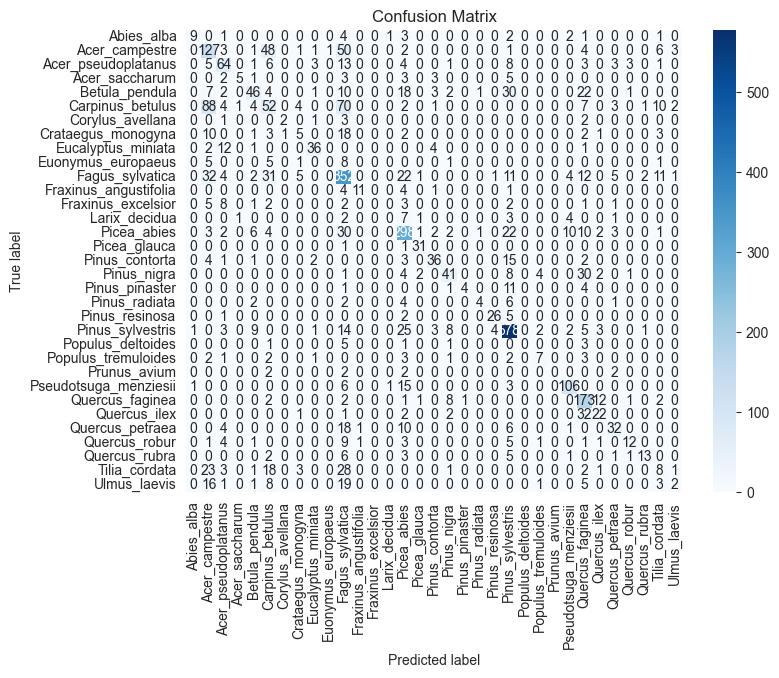

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix (if not already computed)
cm = confusion_matrix(y_val_encoded, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

# 1. Setup
X = train_df[feature_cols]
y = y_train_encoded

# 2. Define the "Selector"
# n_features_to_select=5 means "Keep only the top 5 best features"
rf = RandomForestClassifier(n_estimators=50, random_state=42)
rfe = RFE(estimator=rf, n_features_to_select=8)

# 3. Fit (This takes a moment, it trains the model multiple times)
print("Finding the best features...")
rfe.fit(X, y)

# 4. See results
ranking = pd.DataFrame({'Feature': feature_cols, 'Rank': rfe.ranking_, 'Keep': rfe.support_})
print(ranking.sort_values(by='Rank'))

Finding the best features...
           Feature  Rank   Keep
1           height     1   True
2      crown_ratio     1   True
7   p10_height_rel     1   True
4       crown_area     1   True
11    stem_quality     1   True
10   stem_diameter     1   True
9   p90_height_rel     1   True
8   p50_height_rel     1   True
5   crown_diameter     2  False
3     crown_volume     3  False
0      crown_ratio     4  False
6     trunk_height     5  False
12      is_sapling     6  False
